# **01 - Config Google Colab and Google Drive for pipeline SWIFT**




In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After install -> restart session.

In [2]:
# # 5~ minutes
# !pip install -U "ms-swift[all]"
# !pip install -U vllm
# !pip install U "torchao>=0.16.0"
# !pip install datasets==2.18.0
# !pip install numpy==1.26.4
# !pip install --force-reinstall scipy==1.11.4
# !pip install transformers==4.51.3
!pip install Levenshtein==0.26.1 plotnine==0.14.5 evaluate==0.4.4 cer==1.2.0 rouge_score==0.1.2
!pip install hf_transfer seaborn bitsandbytes python-dateutil --quiet
!pip install jiwer
!pip install huggingface_hub==0.25.2
!pip install pypdfium2==4.30.1 pandas Pillow tqdm --quiet
import torch
import datasets
import torchao
import swift
import numpy
import scipy

print(torch.__version__)
print(datasets.__version__)
print(torchao.__version__)
print(swift.__version__)
print(numpy.__version__)
print(scipy.__version__)

# 2.11.0+cu130
# 2.18.0
# 0.17.0
# 4.2.3
# 1.26.4
# 1.11.4

2.11.0+cu128
2.18.0
0.17.0
4.3.0
1.26.4
1.11.4


In [ ]:
# !pip install qwen-vl-utils decord optimum


# !pip install liger-kernel

# 02 - Create Swift Format Dataset


In [ ]:
# %run ./002_create_custom_dataset_swift_local.ipynb
%run ./002_create_custom_dataset_swift_prompt.ipynb


Ready
PROMPT_MODES      : {'schema_file': 1, 'schema': 0, 'json_label': 0, 'field_list': 0}
Active components : ['schema_file']
Dataset tag       : prompt_schema_file
Output dir        : data/swift_dataset/prompt_schema_file
Split             : TRAIN=80%  DEV=0%  TEST=20%
Found 104 label files


Loading: 100%|██████████| 104/104 [00:00<00:00, 165.35it/s]


Loaded 104 records

Distribution:
doc_type
aus_driver_license/vic      17
aus_medicare_card/blue      14
aus_medicare_card/green     11
aus_medicare_card/yellow    11
aus_passport                26
aus_wwc_card/vic            25
Document Type                                  N  Train   Dev  Test
-----------------------------------------------------------------
aus_driver_license/vic                        17     14     0     3
aus_medicare_card/blue                        14     12     0     2
aus_medicare_card/green                       11      9     0     2
aus_medicare_card/yellow                      11      9     0     2
aus_passport                                  26     21     0     5
aus_wwc_card/vic                              25     20     0     5
-----------------------------------------------------------------
TOTAL                                        104     85     0    19
PROMPT PREVIEW  (active: ['schema_file'])
--- aus_driver_license/vic ---
Document image: <image

train: 100%|██████████| 85/85 [00:45<00:00,  1.87it/s]


  train: 85 samples → conversations_train_swift_format.json


dev: 0it [00:00, ?it/s]


  dev: 0 samples → conversations_dev_swift_format.json


test: 100%|██████████| 19/19 [00:10<00:00,  1.86it/s]

  test: 19 samples → conversations_test_swift_format.json
TRAIN (85 samples):
  AUS_DRIVER_LICENSE: 14
  AUS_MEDICARE_CARD: 30
  AUS_PASSPORT: 21
  AUS_WWC_CARD: 20

DEV (0 samples):

TEST (19 samples):
  AUS_DRIVER_LICENSE: 3
  AUS_MEDICARE_CARD: 6
  AUS_PASSPORT: 5
  AUS_WWC_CARD: 5
=== First train sample ===
Images          : ['/content/drive/.shortcut-targets-by-id/1OmyW8Gv3BtepSewQykHB0uBO8TrQr6IQ/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/data/swift_dataset/images/aus_driver_license_vic_00008.png']
Active modes    : ['schema_file']

[SYSTEM]
You are a document processing expert specialized in extracting structured information from official Australian identity and government documents. Always respond with valid JSON only, no extra text or explanation.

[USER]
Document image: <image>

Context: This is an Australian Driver's Licence (VIC). The document has a front side and a back side — extract both.
- front_holder_*: name fields on the front of the card

In [ ]:
import torch
# kiem tra CUDA
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    free = reserved - allocated

    print(f"Total VRAM: {total:.2f} GB")
    print(f"Allocated: {allocated:.2f} GB")
    print(f"Reserved: {reserved:.2f} GB")
    print(f"Free inside reserved: {free:.2f} GB")

CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
Total VRAM: 14.56 GB
Allocated: 0.00 GB
Reserved: 0.00 GB
Free inside reserved: 0.00 GB


Check length

In [ ]:

import json
import os
from swift import sft_main
# using absolute path
dataset_dir = "/content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/data/swift_dataset/prompt_schema_file"

train_dataset = os.path.join(dataset_dir, "conversations_train_swift_format.json")
val_dataset = os.path.join(dataset_dir, "conversations_test_swift_format.json")
output_dir = "/content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune"


with open(train_dataset) as f:
    data = json.load(f)

lengths = [len(str(item)) for item in data]
print(f"Max: {max(lengths)}, Mean: {sum(lengths)//len(lengths)}, P95: {sorted(lengths)[int(len(lengths)*0.95)]}")

Max: 4555, Mean: 2755, P95: 4544


# 03 - Finetune Qwen2-VL-2B

In [ ]:

argv = [
    "--model_type", "qwen2_vl",
    "--model", "Qwen/Qwen2-VL-2B-Instruct",
    "--tuner_type", "lora",
    "--use_dora", "false", # true
    "--output_dir", output_dir,
    "--max_length", "4560", # 4096
    "--max_pixels", "262144",   # 262144 = 512x512, 150528 = 256x256 reduce if out memory.
    "--dataset", train_dataset,
    "--val_dataset", val_dataset,
    "--save_steps", "50",
    "--logging_steps","5",
    "--num_train_epochs", "4",
    "--lora_dtype", "bfloat16",
    "--per_device_train_batch_size", "1",
    "--per_device_eval_batch_size", "1",
    "--learning_rate", "1e-4", # "4.0e-5", #  "2e-4"
    "--target_modules", "all-linear",
    "--use_hf", "true",
    "--warmup_ratio","0.05",
    "--save_total_limit","3",
    "--gradient_accumulation_steps","8",
    "--gradient_checkpointing", "true",
    "--freeze_vit", "true", # default: true
    "--freeze_llm", "false", # default: false
    "--freeze_aligner", "true" # default: true
]

result = sft_main(argv)
print("Best model checkpoint:", result["best_model_checkpoint"])

[INFO:swift] rank: -1, local_rank: -1, world_size: 1, local_world_size: 1
[INFO:swift] Downloading the model from HuggingFace Hub, model_id: Qwen/Qwen2-VL-2B-Instruct
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

LICENSE: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

...

{'eval_loss': 0.04472726, 'eval_runtime': 55.6208, 'eval_samples_per_second': 0.342, 'eval_steps_per_second': 0.342, 'eval_token_acc': 0.98341336, 'epoch': 3.66, 'global_step/max_steps': '40/40', 'elapsed_time': '34m 37s', 'remaining_time': '0s', 'memory(GiB)': 14.34, 'train_speed(s/it)': 51.92331}


[INFO:swift] Saving model checkpoint to /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v23-20260611-154837/checkpoint-40
Train: 100%|██████████| 40/40 [34:39<00:00, 51.98s/it]
[INFO:swift] last_model_checkpoint: /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v23-20260611-154837/checkpoint-40
[INFO:swift] best_model_checkpoint: /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v23-20260611-154837/checkpoint-40
[INFO:swift] images_dir: /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v23-20260611-154837/images


{'train_runtime': 2079.1075, 'train_samples_per_second': 0.164, 'train_steps_per_second': 0.019, 'train_loss': 0.16406218, 'epoch': 3.66, 'global_step/max_steps': '40/40', 'elapsed_time': '34m 39s', 'remaining_time': '0s', 'memory(GiB)': 14.34, 'train_speed(s/it)': 51.97682}


[INFO:swift] End time of running main: 2026-06-11 16:24:38.966657


Best model checkpoint: /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v23-20260611-154837/checkpoint-40


# **4. inference**


In [ ]:
# CUDA version PyTorch no match CUDA Colab:
# import subprocess
# subprocess.run('apt-get update && apt-get install -y cuda-toolkit-13-0', shell=True)

# subprocess.run('ln -sf /usr/local/cuda/lib64/libnvrtc-builtins.so.13.0 /usr/lib/x86_64-linux-gnu/libnvrtc-builtins.so.13.0', shell=True)
# subprocess.run('ldconfig', shell=True)

# import os
# os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

# run ~5 minute


In [ ]:

# fix bug arget modules ^(model\.language_model(?=\.).*\/...
# import json
# from pathlib import Path

# CHECKPOINT = "/content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v16-20260603-014633/checkpoint-145"
# cfg_path = Path(CHECKPOINT) / 'adapter_config.json'
# with open(cfg_path) as f:
#     cfg = json.load(f)

# cfg['target_modules'] = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']

# with open(cfg_path, 'w') as f:
#     json.dump(cfg, f, indent=2)

# print(f"Fixed: {cfg_path}")

Fixed: /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v16-20260603-014633/checkpoint-145/adapter_config.json


In [ ]:
# from swift import infer_main

# CHECKPOINT = "/content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v19-20260606-052332/checkpoint-40"
# # adapters = new checkpoint.

# infer_argv = [
#     "--model_type", "qwen2_vl",
#     "--model", "Qwen/Qwen2-VL-2B-Instruct",
#     "--adapters", f"{CHECKPOINT}",
#     "--max_pixels", "262144",
#     "--max_new_tokens", "512",
#     "--stream", "false",
# ]

# infer_main(infer_argv)

# example path
# /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/data/documents/aus_passport/aus_passport_00002.jpg

[INFO:swift] Successfully loaded /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v19-20260606-052332/checkpoint-40/args.json.
[INFO:swift] rank: -1, local_rank: -1, world_size: 1, local_world_size: 1
[INFO:swift] Downloading the model from HuggingFace Hub, model_id: Qwen/Qwen2-VL-2B-Instruct


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

[INFO:swift] Loading the model using model_dir: /root/.cache/huggingface/hub/models--Qwen--Qwen2-VL-2B-Instruct/snapshots/895c3a49bc3fa70a340399125c650a463535e71c
[WARNING:swift] Please install the package: `pip install "decord" -U`.
[INFO:swift] Setting args.eval_human: True
[INFO:swift] Setting args.lazy_tokenize: True
[INFO:swift] args: InferArguments(use_ray=False, ray_exp_name=None, device_groups=None, model='Qwen/Qwen2-VL-2B-Instruct', model_type='qwen2_vl', model_revision=None, task_type='causal_lm', torch_dtype=torch.bfloat16, attn_impl=None, experts_impl=None, new_special_tokens=[], num_labels=None, problem_type=None, rope_scaling=None, device_map=None, max_memory={}, max_model_len=None, local_repo_path=None, init_strategy=None, template='qwen2_vl', system=None, max_length=32768, truncation_strategy='delete', max_pixels=262144, agent_template=None, norm_bbox=None, use_chat_template=True, padding_side='right', padding_free=False, loss_scale='default', sequence_parallel_size=1, 

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

[INFO:swift] Loading the model using model_dir: /root/.cache/huggingface/hub/models--Qwen--Qwen2-VL-2B-Instruct/snapshots/895c3a49bc3fa70a340399125c650a463535e71c
[WARNING:swift] Please install the package: `pip install "decord" -U`.
[INFO:swift] model_kwargs: {'device_map': 'cuda:0', 'torch_dtype': torch.bfloat16}


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[INFO:swift] default_system: 'You are a helpful assistant.'
[INFO:swift] max_length: 32768
[INFO:swift] response_prefix: ''
[INFO:swift] agent_template: hermes
[INFO:swift] norm_bbox: norm1000
[INFO:swift] model: PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2VLForConditionalGeneration(
      (visual): Qwen2VisionTransformerPretrainedModel(
        (patch_embed): PatchEmbed(
          (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
        )
        (rotary_pos_emb): VisionRotaryEmbedding()
        (blocks): ModuleList(
          (0-31): 32 x Qwen2VLVisionBlock(
            (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
            (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
            (attn): VisionSdpaAttention(
              (qkv): Linear(in_features=1280, out_features=3840, bias=True)
              (proj): Linear(in_features=1280, out_features=1280, bias=True)
            )
            (mlp):

<<< <<image>> extracu data from image with json format
Input an image path or URL <<< /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/data/documents/aus_passport/aus_passport_00012.jpg
{"AUS_PASSPORT": {"card_number": "IQ0184183", "expiry_date": "2030-04-04", "holder_name": "EDWARD DAY", "gender": "M", "dob": "1961-05-21", "nationality": "AUSTRALIAN", "dob_in_location": "GEELONG", "dob_in_year": "1961", "expiry_in_location": "CANBERRA", "expiry_in_year": "2030", "card_type": "P", "card_number_type": "AUS_PASSPORT", "card_number": "P<AUSDAY<<EDWARD<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<IQ0518418<AUS610521M300404<<<<<<<<<<<<<<<<01"}}
--------------------------------------------------
<<< <<image>> extract data from image with json format
Input an image path or URL <<< /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/data/swift_dataset/images/aus_driver_license_vic_00001.png
{"AUS_DRIVER_LICENSE": {"c

[INFO:swift] End time of running main: 2026-06-10 08:40:08.000213


[{'response': '{"AUS_PASSPORT": {"card_number": "IQ0184183", "expiry_date": "2030-04-04", "holder_name": "EDWARD DAY", "gender": "M", "dob": "1961-05-21", "nationality": "AUSTRALIAN", "dob_in_location": "GEELONG", "dob_in_year": "1961", "expiry_in_location": "CANBERRA", "expiry_in_year": "2030", "card_type": "P", "card_number_type": "AUS_PASSPORT", "card_number": "P<AUSDAY<<EDWARD<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<IQ0518418<AUS610521M300404<<<<<<<<<<<<<<<<01"}}',
  'messages': [{'role': 'user',
    'content': '<<image>> extracu data from image with json format'},
   {'role': 'assistant',
    'content': '{"AUS_PASSPORT": {"card_number": "IQ0184183", "expiry_date": "2030-04-04", "holder_name": "EDWARD DAY", "gender": "M", "dob": "1961-05-21", "nationality": "AUSTRALIAN", "dob_in_location": "GEELONG", "dob_in_year": "1961", "expiry_in_location": "CANBERRA", "expiry_in_year": "2030", "card_type": "P", "card_number_type": "AUS_PASSPORT", "card_number": "P<AUSDAY<<EDWARD<<<<<<<<<<<<<<<<<<<<<

In [ ]:
# {
#   "document_type": "",
#   "issuing_country": "",
#   "document_number": "",
#   "family_name": "",
#   "given_names": "",
#   "nationality": "",
#   "date_of_birth": "",
#   "sex": "F",
#   "date_of_issue": "",
#   "date_of_expiry": "",
#   "place_of_birth": "",
#   "authority": "",
#   "mrz_line1": "",
#   "mrz_line2": ""
# }

# # /content/drive/MyDrive/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/data/swift_dataset/images/aus_driver_license_vic_00001.png
# {
#   "document_type": "",
#   "issuing_state": "",
#   "front": {
#     "holder": {
#       "first_name": "",
#       "middle_name": "",
#       "last_name": "",
#       "full_name": "",
#       "sex": "",
#       "dob": ""
#     },
#     "licence": {
#       "licence_number": "",
#       "licence_classes": [],
#       "licence_type_raw": "",
#       "expiry_date": "",
#       "conditions": []
#     },
#     "address": {
#       "address_line_1": "",
#       "address_line_2": "",
#       "suburb": "",
#       "state": "",
#       "postcode": ""
#     },
#     "card_number": "",
#     "dob_watermark": "",
#     "photo_present": "",
#     "signature_present": ""
#   },
#   "back": {
#     "card_number": "",
#     "expiry_date": "",
#     "dob": "",
#     "age_indicator": "",
#     "barcode_number": "",
#     "conditions_legend": {

#     },
#     "transport_notice": ""
#   }
# }


# 05 - Evaluation

In [ ]:
# Check vram

# import torch, gc
# gc.collect()
# torch.cuda.empty_cache()
# free = torch.cuda.mem_get_info()[0]/1024**3
# print(f"VRAM free: {free:.1f} GB")

VRAM free: 4.8 GB


Ready
Auto-selected latest checkpoint: /content/drive/.shortcut-targets-by-id/1OmyW8Gv3BtepSewQykHB0uBO8TrQr6IQ/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v22-20260610-075050/checkpoint-40
MODEL_NAME : v22-20260610-075050

All valid checkpoints:
  v19-20260606-052332/checkpoint-40
  v20-20260610-043105/checkpoint-36
  v22-20260610-075050/checkpoint-40  ← ACTIVE
BASE_DIR    : /content/drive/.shortcut-targets-by-id/1OmyW8Gv3BtepSewQykHB0uBO8TrQr6IQ/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai
CHECKPOINT  : /content/drive/.shortcut-targets-by-id/1OmyW8Gv3BtepSewQykHB0uBO8TrQr6IQ/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v22-20260610-075050/checkpoint-40
MODEL_NAME  : v22-20260610-075050
CACHE_FILES : [('/content/drive/.shortcut-targets-by-id/1OmyW8Gv3BtepSewQykHB0uBO8TrQr6IQ/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/rows_cache.json', 'auto')]


[INFO:swift] Successfully registered `/usr/local/lib/python3.12/dist-packages/swift/dataset/data/dataset_info.json`.
[INFO:swift] Successfully loaded /content/drive/.shortcut-targets-by-id/1OmyW8Gv3BtepSewQykHB0uBO8TrQr6IQ/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/models/finetune/v22-20260610-075050/checkpoint-40/args.json.
[INFO:swift] rank: -1, local_rank: -1, world_size: 1, local_world_size: 1
[INFO:swift] Downloading the model from HuggingFace Hub, model_id: Qwen/Qwen2-VL-2B-Instruct
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access pub

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/19 [00:00<?, ? examples/s]

[INFO:swift] val_dataset: Dataset({
    features: ['messages', 'images'],
    num_rows: 19
})
100%|██████████| 19/19 [11:33<00:00, 36.52s/it]
[INFO:swift] The inference results have been saved to result_path: `/content/drive/.shortcut-targets-by-id/1OmyW8Gv3BtepSewQykHB0uBO8TrQr6IQ/INTERN-BIWOCO/sample-for-multi-modal-document-to-json-with-sagemaker-ai/infer_results.jsonl`.
[INFO:swift] End time of running main: 2026-06-12 01:47:40.017206


{'num_prompt_tokens': 37884, 'num_generated_tokens': 4209, 'num_samples': 19, 'runtime': 693.8233868369998, 'samples/s': 0.0273844905785277, 'tokens/s': 6.066385307632793}

=== DEBUG KIỂM TRA PROMPT VÀ JSON LABEL NULL ===
System Message: You are a document processing expert specialized in extracting structured information from official Australian identity and government documents. Always respond with valid JSON only, no extra text or explanation.
User Prompt: Document image: <image>

Context: This is an Australian Driver's Licence. - age_indicator: format DD-YY (birth day - birth year last 2 digits), e.g. '08-04'
- barcode_number: starts with 'AB', 18+ chars, copy exactly as printed
- dob_watermark: 8 digits DDMMYYYY with NO separators, e.g. '09092004'
- full_name in front.holder: first_name + last_name only, no title
- transport_notice: copy full text exactly, do not truncate


Extract all fields and return ONLY valid JSON matching this structure:
{
  "document_type": null,
  "issuing

### All Entities

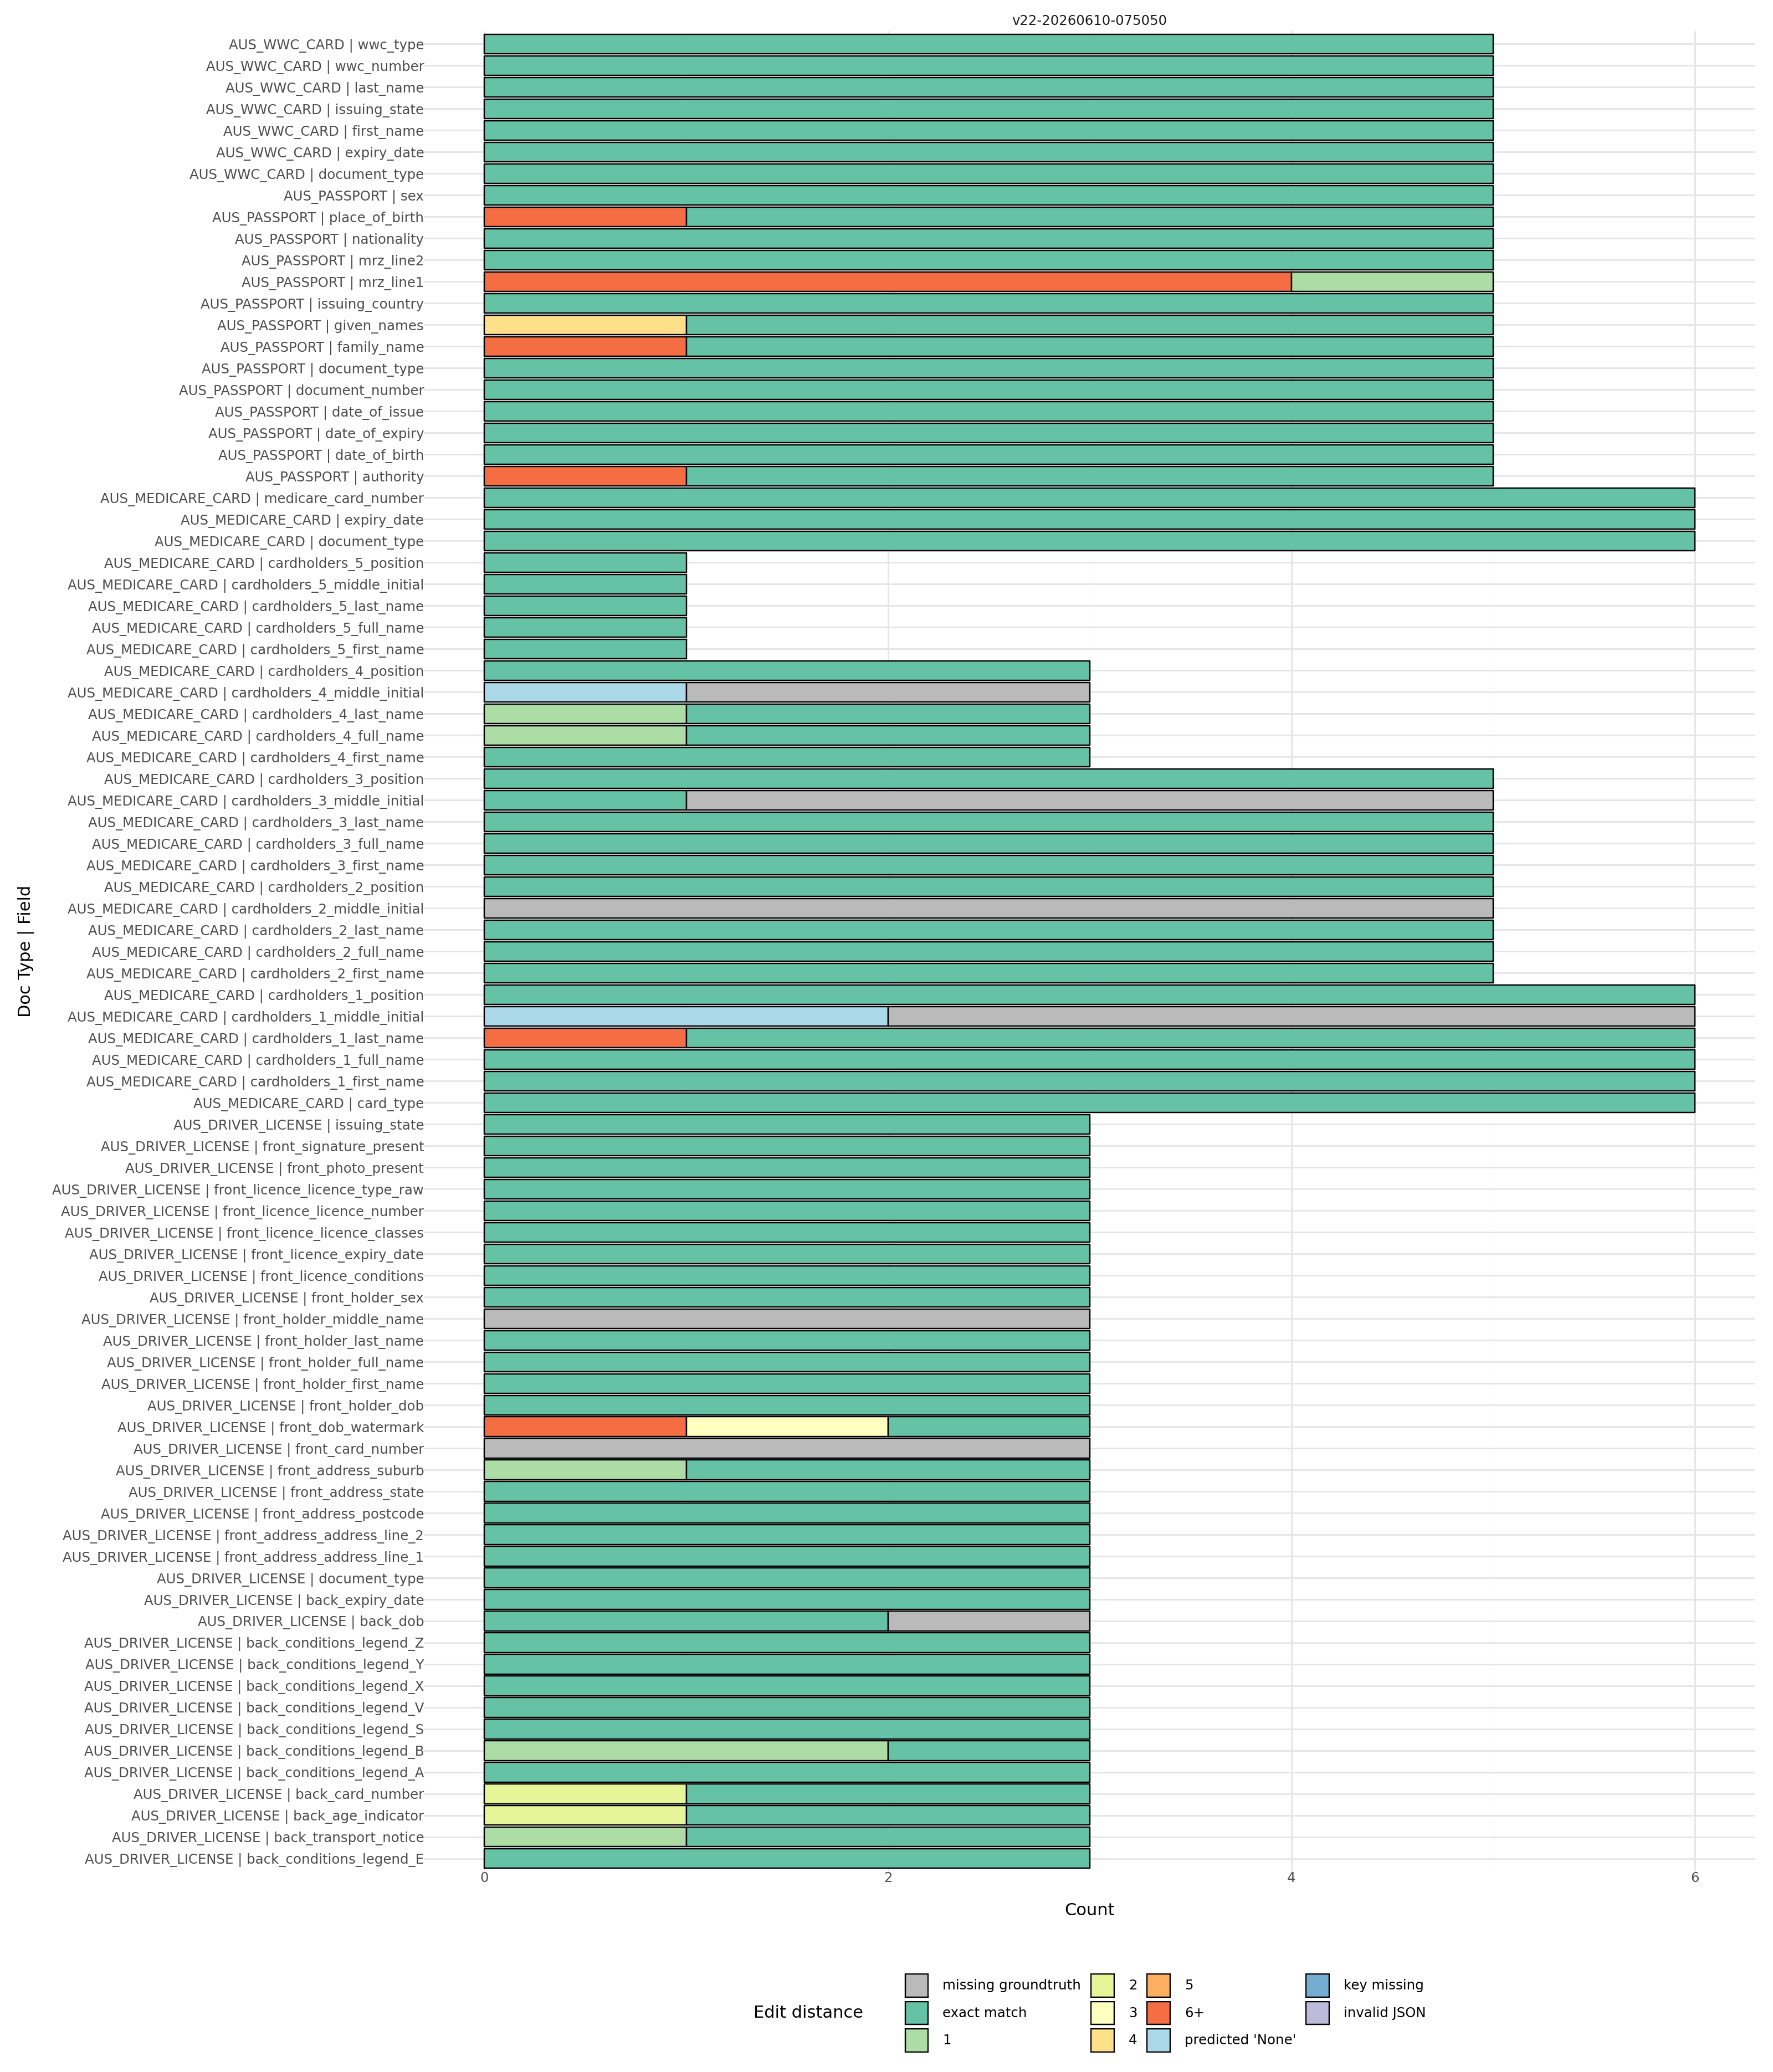

### AUS_DRIVER_LICENSE

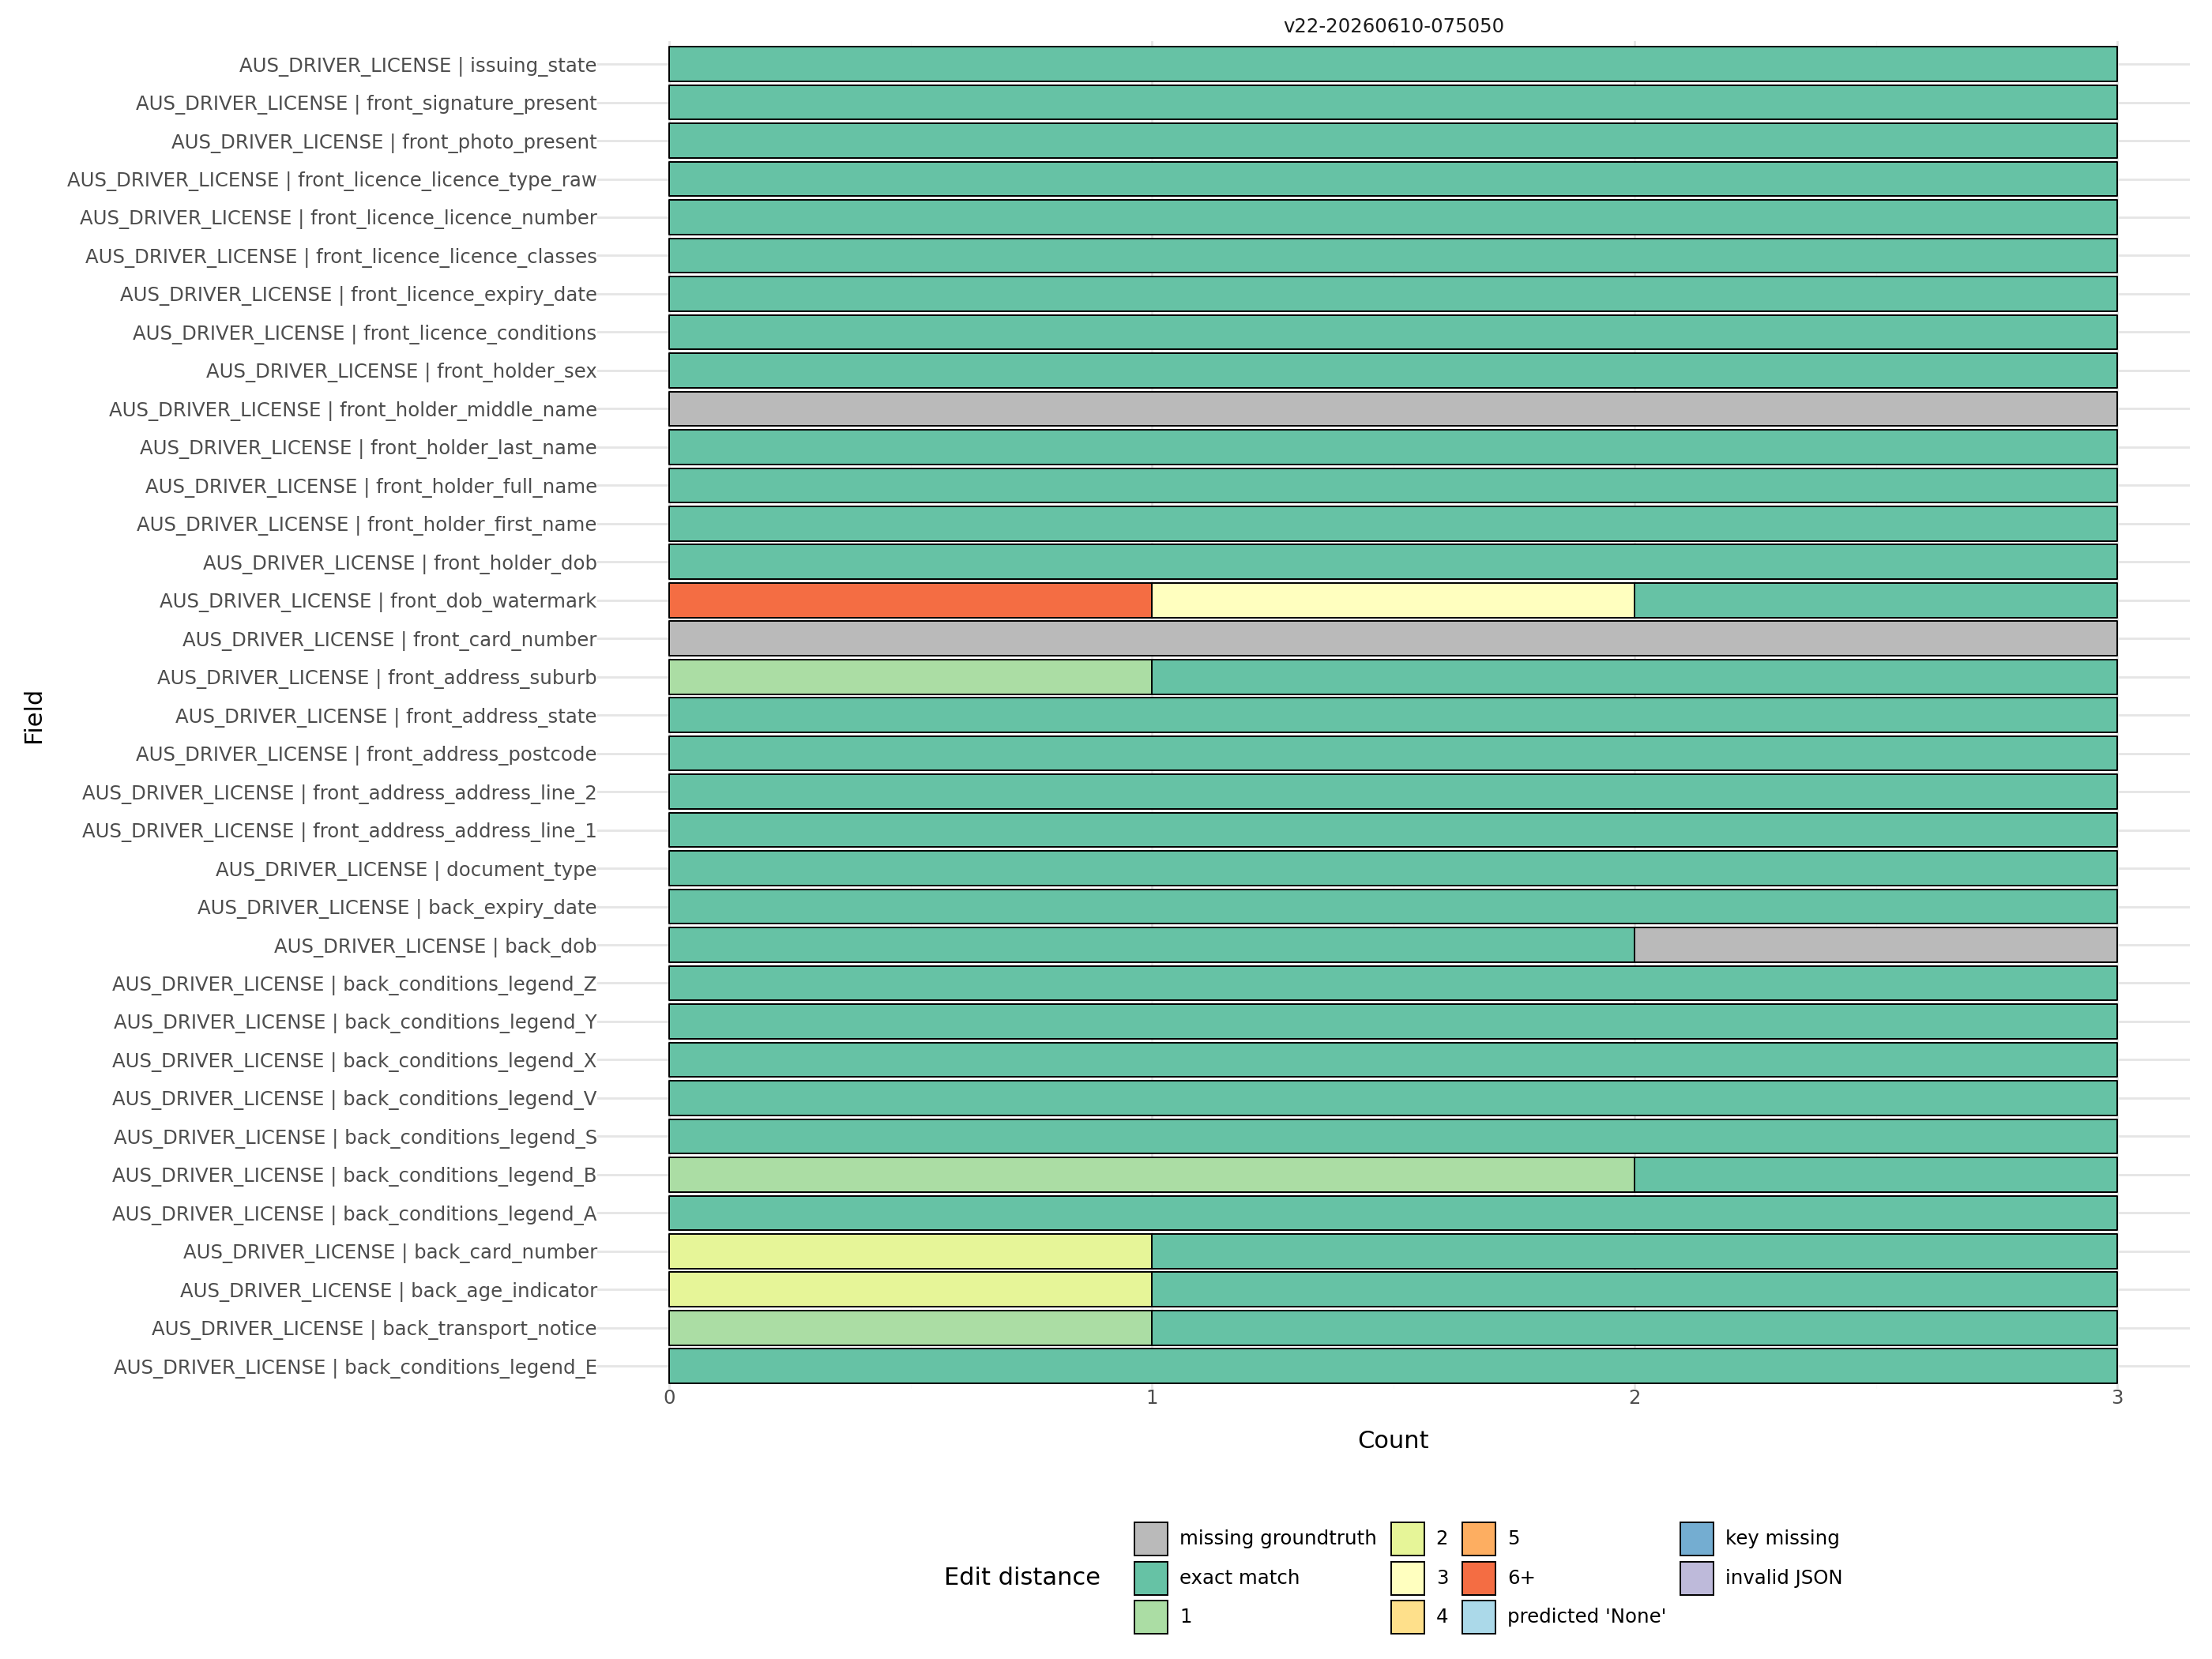

### AUS_MEDICARE_CARD

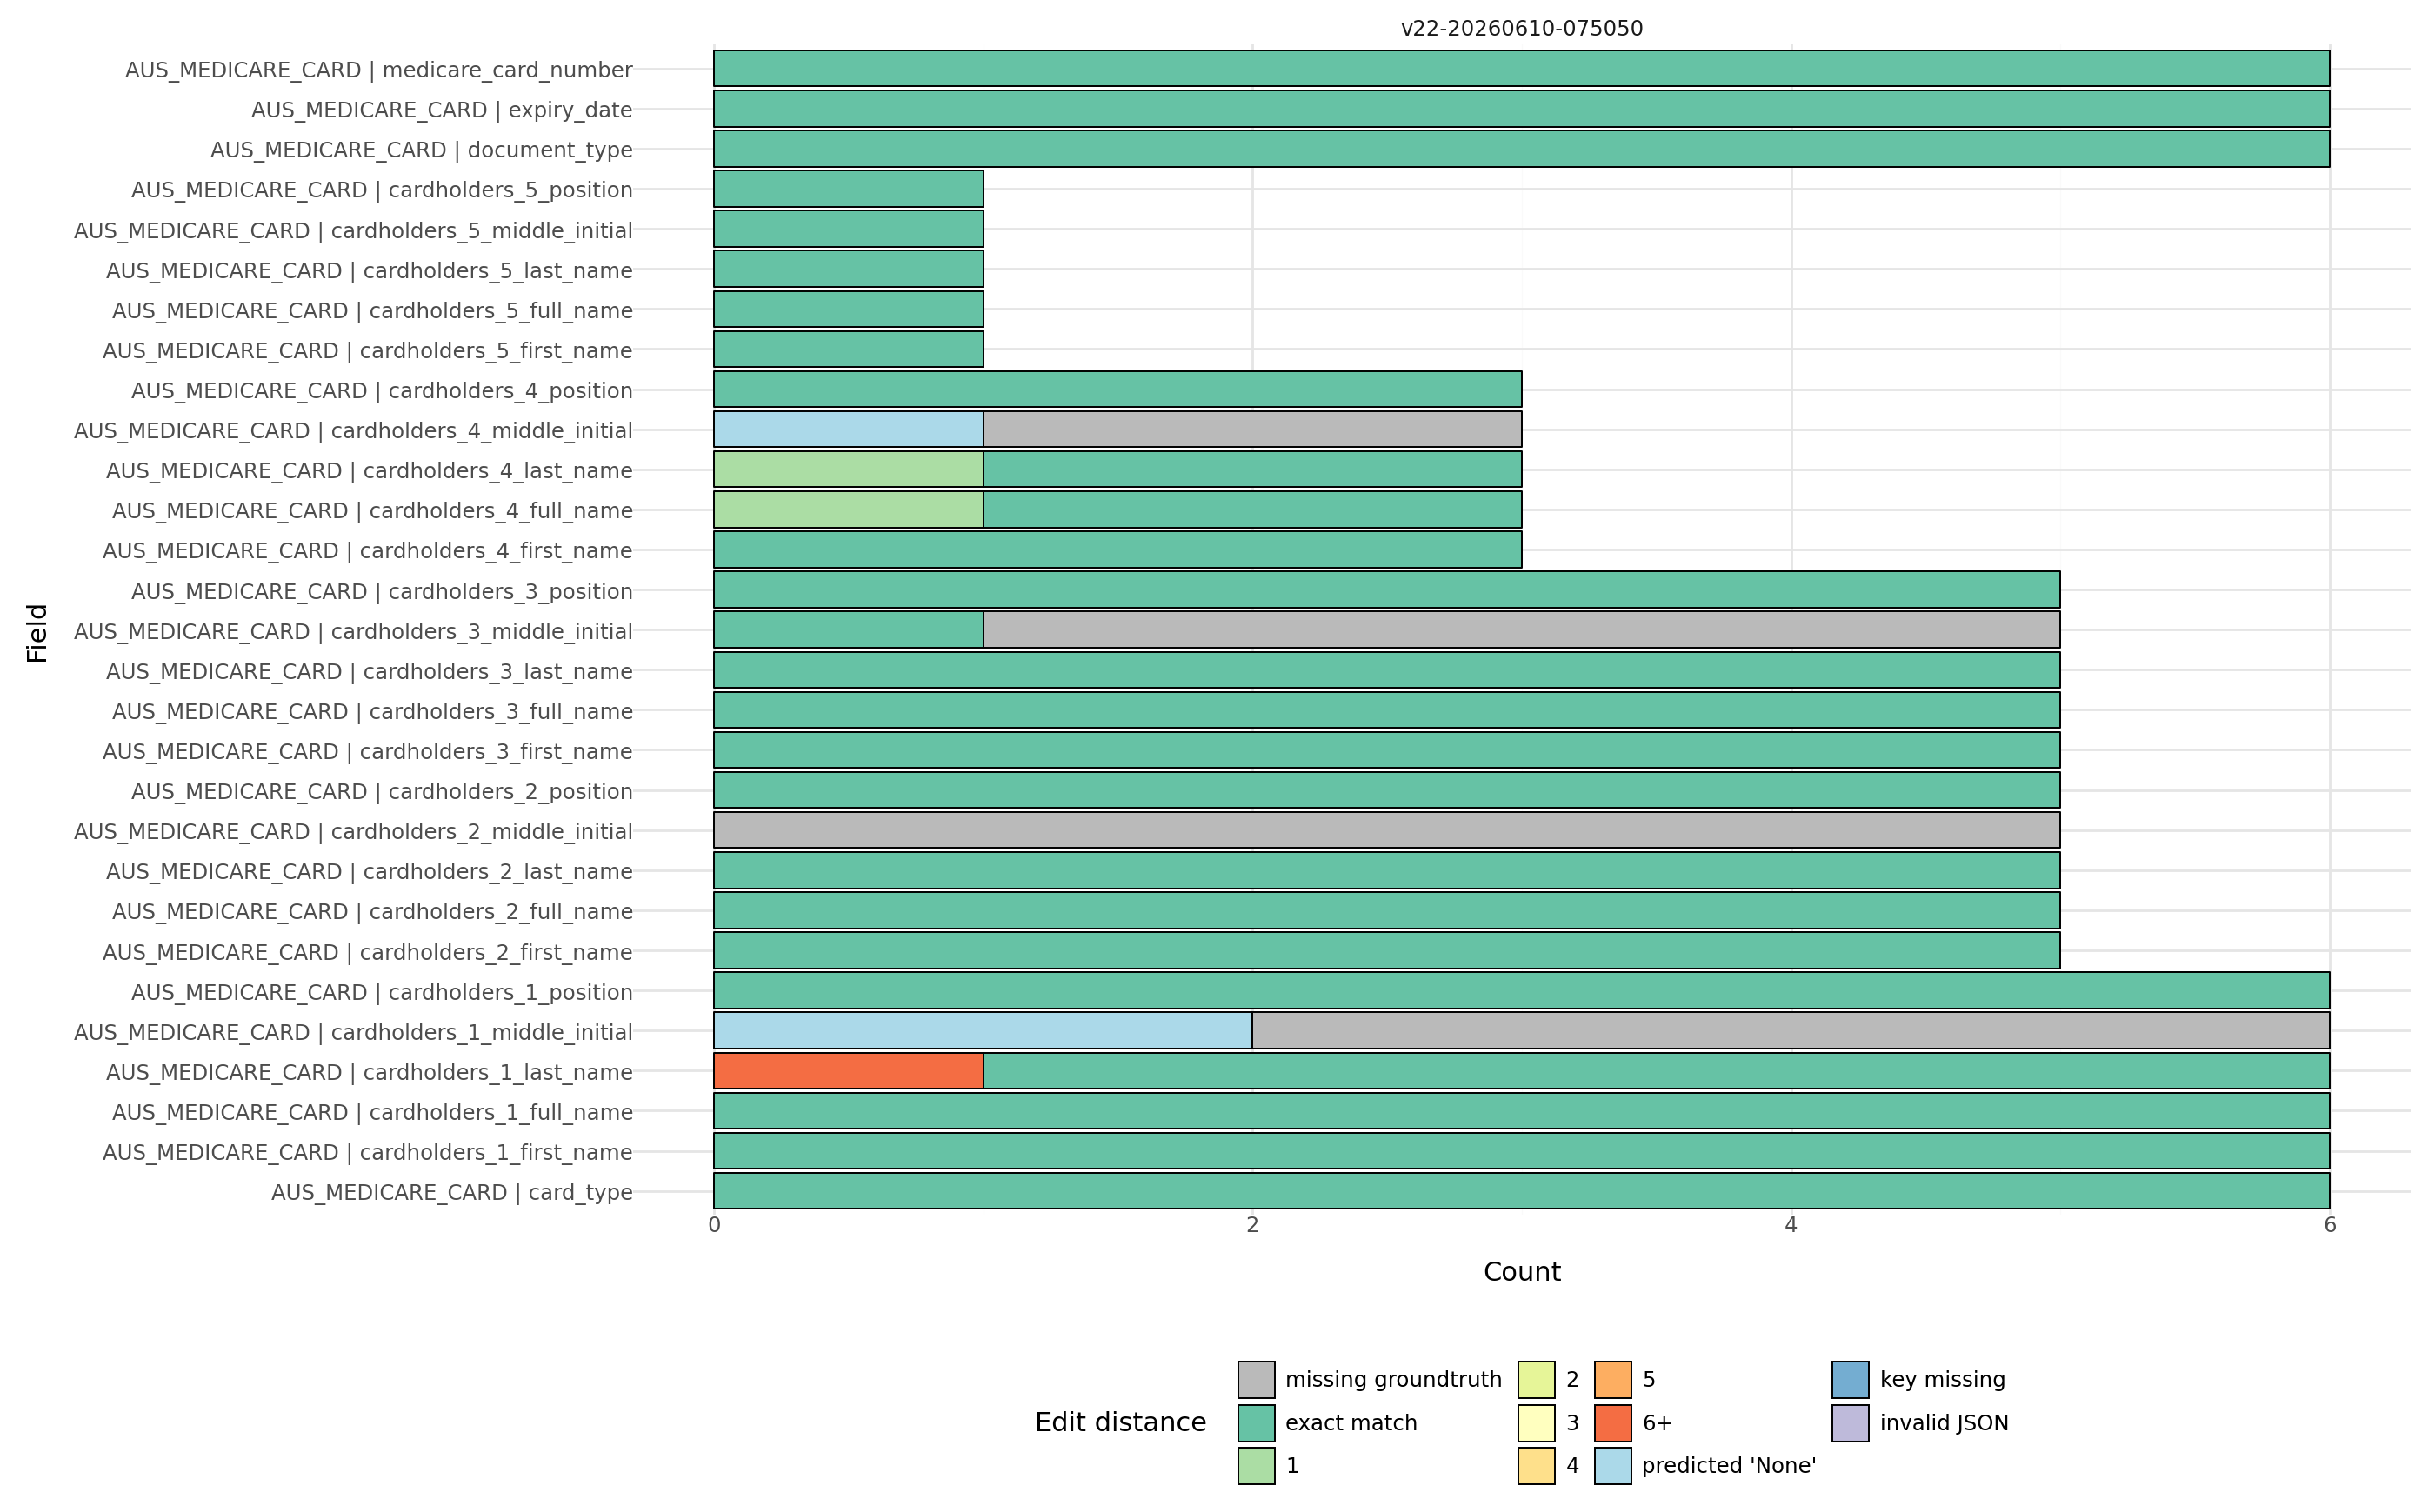

### AUS_PASSPORT

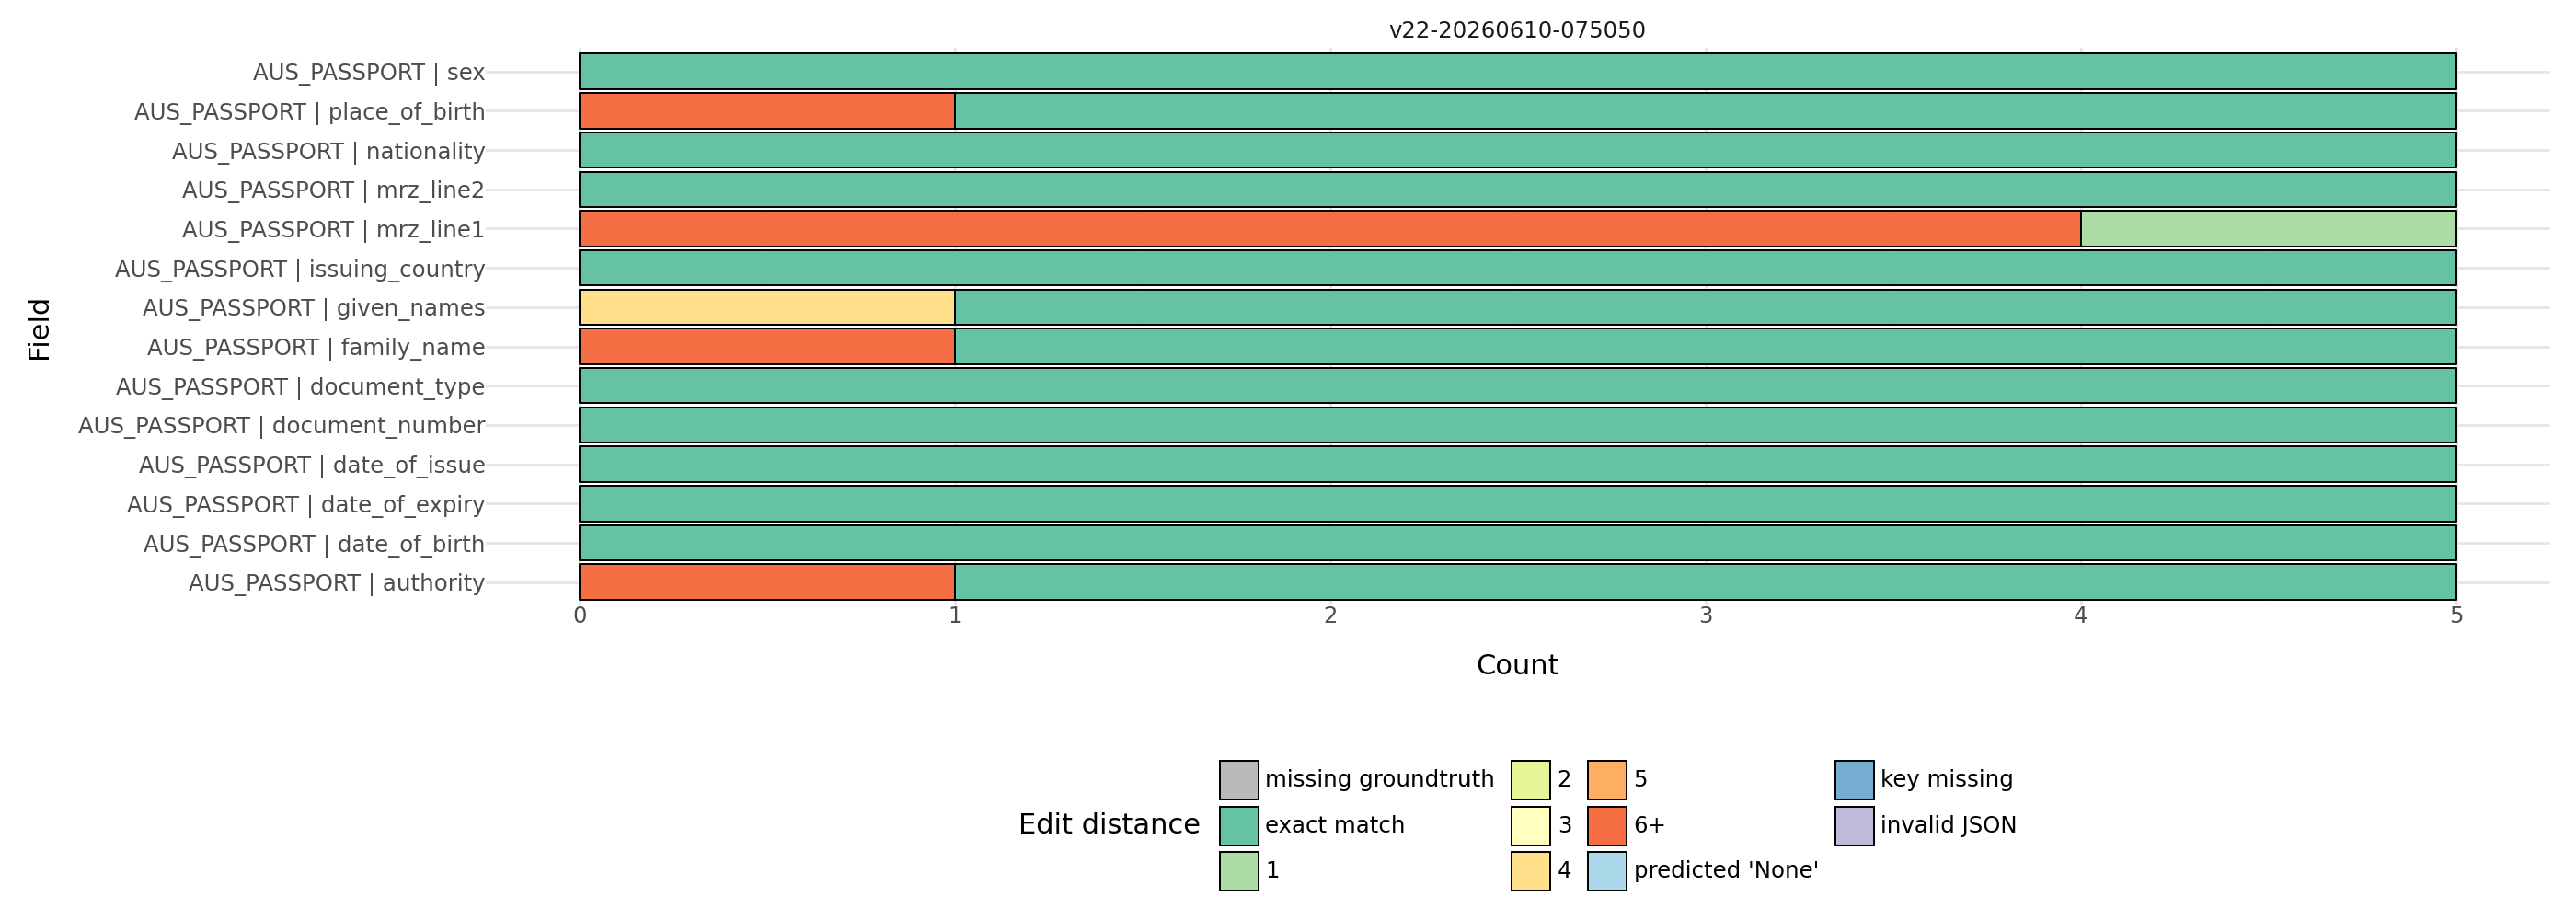

### AUS_WWC_CARD

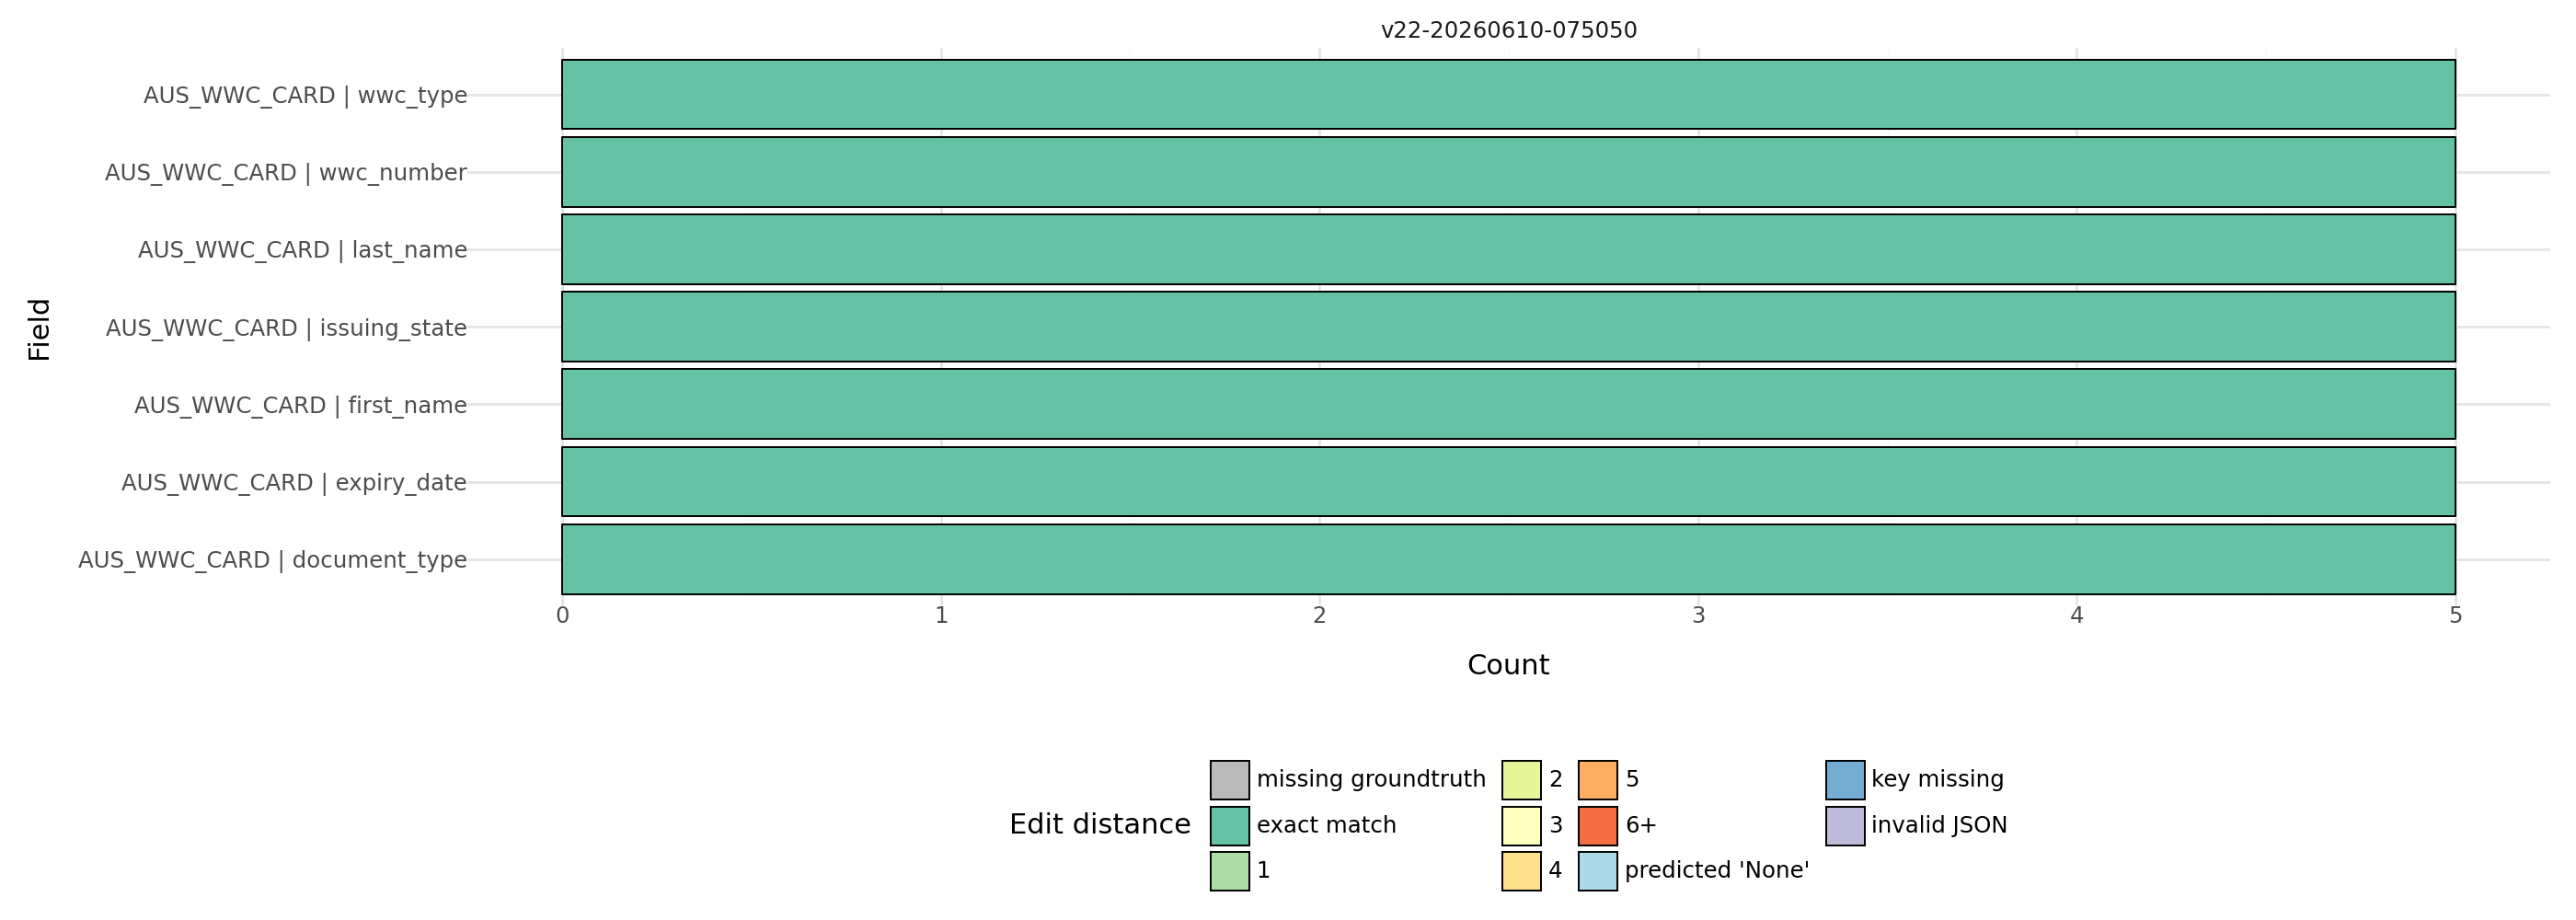

Metrics ready: ['exact_match', 'bleu', 'rouge', 'cer']
df_eval: (80, 16)


,pretty_name,exact_match,cer_score,rouge1,rouge2,rougeL
0,v22-20260610-075050,0.872200,0.000000,0.994000,0.987700,0.994000


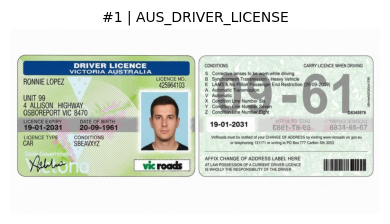

✓ valid JSON


Field,Ground Truth,Prediction
✓ back_age_indicator,09-61,09-61
✗ back_barcode_number,ABNOTENZ9454292768,AB768AIZ08034378S
✓ back_card_number,D8345976,D8345976
✓ back_conditions_legend_A,AUTOMATIC TRANSMISSION,AUTOMATIC TRANSMISSION
✓ back_conditions_legend_B,SYNCHROMESH TRANSMISSION - HEAVY VEHICLE,SYNCHROMESH TRANSMISSION - HEAVY VEHICLE
✓ back_conditions_legend_E,LAMS & NO PILLION PASSENGER END RESTRICTION (20-09-2009),LAMS & NO PILLION PASSENGER END RESTRICTION (20-09-2009)
✓ back_conditions_legend_S,CORRECTIVE LENSES TO BE WORN WHILE DRIVING,CORRECTIVE LENSES TO BE WORN WHILE DRIVING
✓ back_conditions_legend_V,AUTOMATIC,AUTOMATIC
✓ back_conditions_legend_X,CONDITION LINE NUMBER SIX,CONDITION LINE NUMBER SIX
✓ back_conditions_legend_Y,CONDITION LINE NUMBER SEVEN,CONDITION LINE NUMBER SEVEN


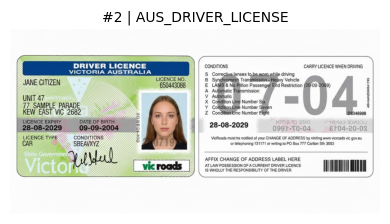

✓ valid JSON


Field,Ground Truth,Prediction
✗ back_age_indicator,08-04,09-09
✗ back_barcode_number,ABNOTENZ7780399394,ABW234567890123456789
✗ back_card_number,D8346508,D8346998
✓ back_conditions_legend_A,AUTOMATIC TRANSMISSION,AUTOMATIC TRANSMISSION
✗ back_conditions_legend_B,SYNCHROMESH TRANSMISSION - HEAVY VEHICLE,SYNCHRONMESH TRANSMISSION - HEAVY VEHICLE
✓ back_conditions_legend_E,LAMS & NO PILLION PASSENGER END RESTRICTION (20-09-2009),LAMS & NO PILLION PASSENGER END RESTRICTION (20-09-2009)
✓ back_conditions_legend_S,CORRECTIVE LENSES TO BE WORN WHILE DRIVING,CORRECTIVE LENSES TO BE WORN WHILE DRIVING
✓ back_conditions_legend_V,AUTOMATIC,AUTOMATIC
✓ back_conditions_legend_X,CONDITION LINE NUMBER SIX,CONDITION LINE NUMBER SIX
✓ back_conditions_legend_Y,CONDITION LINE NUMBER SEVEN,CONDITION LINE NUMBER SEVEN


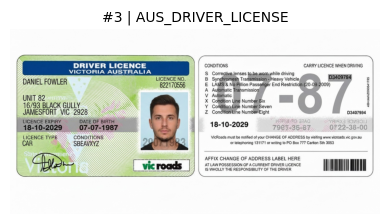

✓ valid JSON


Field,Ground Truth,Prediction
✓ back_age_indicator,07-87,07-87
✗ back_barcode_number,ABNOTENZ4375502226,AB34097841765
✓ back_card_number,D3409784,D3409784
✓ back_conditions_legend_A,AUTOMATIC TRANSMISSION,AUTOMATIC TRANSMISSION
✗ back_conditions_legend_B,SYNCHROMESH TRANSMISSION - HEAVY VEHICLE,SYNCHRONMESH TRANSMISSION - HEAVY VEHICLE
✓ back_conditions_legend_E,LAMS & NO PILLION PASSENGER END RESTRICTION (20-09-2009),LAMS & NO PILLION PASSENGER END RESTRICTION (20-09-2009)
✓ back_conditions_legend_S,CORRECTIVE LENSES TO BE WORN WHILE DRIVING,CORRECTIVE LENSES TO BE WORN WHILE DRIVING
✓ back_conditions_legend_V,AUTOMATIC,AUTOMATIC
✓ back_conditions_legend_X,CONDITION LINE NUMBER SIX,CONDITION LINE NUMBER SIX
✓ back_conditions_legend_Y,CONDITION LINE NUMBER SEVEN,CONDITION LINE NUMBER SEVEN


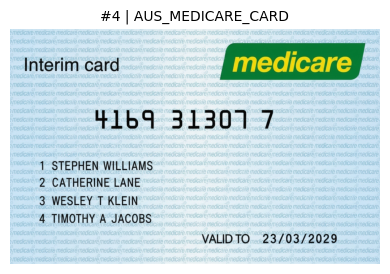

✓ valid JSON


Field,Ground Truth,Prediction
✓ card_type,INTERIM CARD,INTERIM CARD
✓ cardholders_1_first_name,STEPHEN,STEPHEN
✓ cardholders_1_full_name,1 STEPHEN WILLIAMS,1 STEPHEN WILLIAMS
✓ cardholders_1_last_name,WILLIAMS,WILLIAMS
✓ cardholders_1_middle_initial,,
✓ cardholders_1_position,1,1
✓ cardholders_2_first_name,CATHERINE,CATHERINE
✓ cardholders_2_full_name,2 CATHERINE LANE,2 CATHERINE LANE
✓ cardholders_2_last_name,LANE,LANE
✓ cardholders_2_middle_initial,,


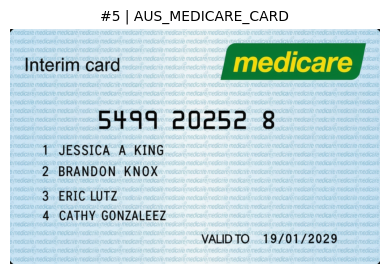

✓ valid JSON


Field,Ground Truth,Prediction
✓ card_type,INTERIM CARD,INTERIM CARD
✓ cardholders_1_first_name,JESSICA,JESSICA
✓ cardholders_1_full_name,1 JESSICA A KING,1 JESSICA A KING
✓ cardholders_1_last_name,KING,KING
✗ cardholders_1_middle_initial,A,
✓ cardholders_1_position,1,1
✓ cardholders_2_first_name,BRANDON,BRANDON
✓ cardholders_2_full_name,2 BRANDON KNOX,2 BRANDON KNOX
✓ cardholders_2_last_name,KNOX,KNOX
✓ cardholders_2_middle_initial,,


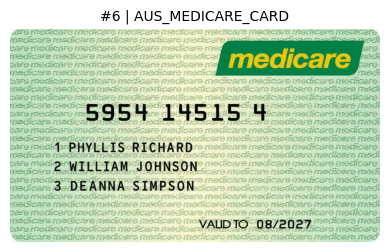

✓ valid JSON


Field,Ground Truth,Prediction
✓ card_type,REGULAR,REGULAR
✓ cardholders_1_first_name,PHYLLIS,PHYLLIS
✓ cardholders_1_full_name,1 PHYLLIS RICHARD,1 PHYLLIS RICHARD
✓ cardholders_1_last_name,RICHARD,RICHARD
✓ cardholders_1_middle_initial,,
✓ cardholders_1_position,1,1
✓ cardholders_2_first_name,WILLIAM,WILLIAM
✓ cardholders_2_full_name,2 WILLIAM JOHNSON,2 WILLIAM JOHNSON
✓ cardholders_2_last_name,JOHNSON,JOHNSON
✓ cardholders_2_middle_initial,,


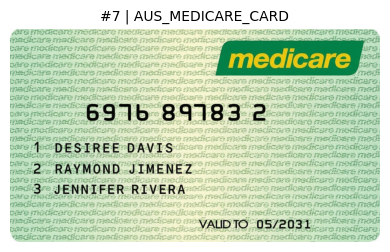

✓ valid JSON


Field,Ground Truth,Prediction
✓ card_type,REGULAR,REGULAR
✓ cardholders_1_first_name,DESIREE,DESIREE
✓ cardholders_1_full_name,1 DESIREE DAVIS,1 DESIREE DAVIS
✓ cardholders_1_last_name,DAVIS,DAVIS
✓ cardholders_1_middle_initial,,
✓ cardholders_1_position,1,1
✓ cardholders_2_first_name,RAYMOND,RAYMOND
✓ cardholders_2_full_name,2 RAYMOND JIMENEZ,2 RAYMOND JIMENEZ
✓ cardholders_2_last_name,JIMENEZ,JIMENEZ
✓ cardholders_2_middle_initial,,


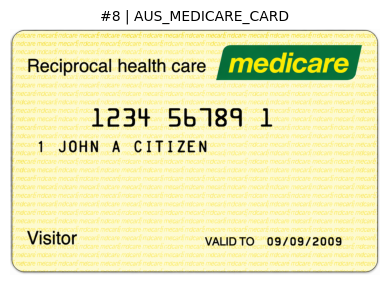

✓ valid JSON


Field,Ground Truth,Prediction
✓ card_type,RECIPROCAL HEALTH CARE,RECIPROCAL HEALTH CARE
✓ cardholders_1_first_name,JOHN,JOHN
✓ cardholders_1_full_name,1 JOHN A CITIZEN,1 JOHN A CITIZEN
✗ cardholders_1_last_name,CITIZEN,A
✗ cardholders_1_middle_initial,A,
✓ cardholders_1_position,1,1
✓ document_type,AUS_MEDICARE_CARD,AUS_MEDICARE_CARD
✓ expiry_date,2009-09-09,2009-09-09
✓ medicare_card_number,1234 56789 1,1234 56789 1


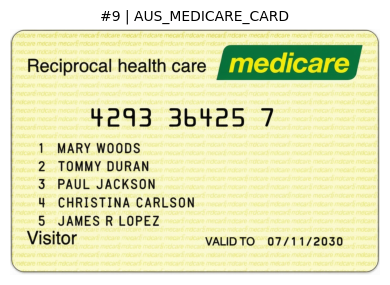

✓ valid JSON


Field,Ground Truth,Prediction
✓ card_type,RECIPROCAL HEALTH CARE,RECIPROCAL HEALTH CARE
✓ cardholders_1_first_name,MARY,MARY
✓ cardholders_1_full_name,1 MARY WOODS,1 MARY WOODS
✓ cardholders_1_last_name,WOODS,WOODS
✓ cardholders_1_middle_initial,,
✓ cardholders_1_position,1,1
✓ cardholders_2_first_name,TOMMY,TOMMY
✓ cardholders_2_full_name,2 TOMMY DURAN,2 TOMMY DURAN
✓ cardholders_2_last_name,DURAN,DURAN
✓ cardholders_2_middle_initial,,


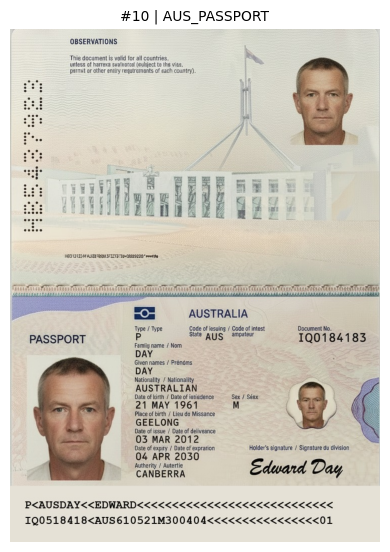

✓ valid JSON


Field,Ground Truth,Prediction
✓ authority,CANBERRA,CANBERRA
✓ date_of_birth,1961-05-21,1961-05-21
✓ date_of_expiry,2030-04-04,2030-04-04
✓ date_of_issue,2012-03-03,2012-03-03
✓ document_number,IQ0184183,IQ0184183
✓ document_type,AUS_PASSPORT,AUS_PASSPORT
✗ family_name,DAY,GEELONG
✗ given_names,DAY,EDWARD
✓ issuing_country,AUS,AUS
✗ mrz_line1,P<AUSDAY<<EDWARD<<<<<<<<<<<<<<<<<<<<<<<<<<<<,P<AUSDAY<<EDWARD<<<<<<<<<<<<<<<<<<<<<<<<<<<


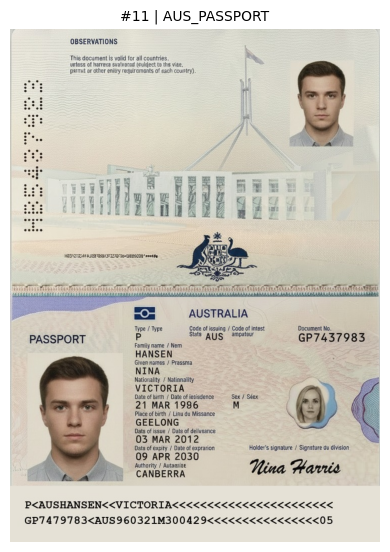

✓ valid JSON


Field,Ground Truth,Prediction
✓ authority,CANBERRA,CANBERRA
✓ date_of_birth,1986-03-21,1986-03-21
✓ date_of_expiry,2030-04-09,2030-04-09
✓ date_of_issue,2012-03-03,2012-03-03
✓ document_number,GP7437983,GP7437983
✓ document_type,AUS_PASSPORT,AUS_PASSPORT
✓ family_name,HANSEN,HANSEN
✓ given_names,NINA,NINA
✓ issuing_country,AUS,AUS
✗ mrz_line1,P<AUSHANSEN<<VICTORIA<<<<<<<<<<<<<<<<<<<<<<<,P<AUSHANSEN<<VICTORIA<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


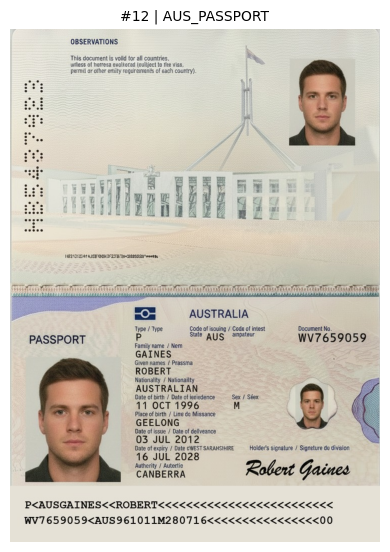

✓ valid JSON


Field,Ground Truth,Prediction
✓ authority,CANBERRA,CANBERRA
✓ date_of_birth,1996-10-11,1996-10-11
✓ date_of_expiry,2028-07-16,2028-07-16
✓ date_of_issue,2012-07-03,2012-07-03
✓ document_number,WV7659059,WV7659059
✓ document_type,AUS_PASSPORT,AUS_PASSPORT
✓ family_name,GAINES,GAINES
✓ given_names,ROBERT,ROBERT
✓ issuing_country,AUS,AUS
✗ mrz_line1,P<AUSGAINES<<ROBERT<<<<<<<<<<<<<<<<<<<<<<<<<,P<AUSGAINES<<ROBERT<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


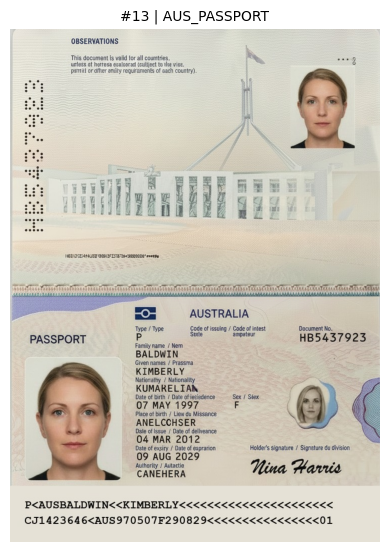

✓ valid JSON


Field,Ground Truth,Prediction
✓ authority,CANEHERA,CANEHERA
✓ date_of_birth,1997-05-07,1997-05-07
✓ date_of_expiry,2029-08-09,2029-08-09
✓ date_of_issue,2012-03-04,2012-03-04
✓ document_number,HB5437923,HB5437923
✓ document_type,AUS_PASSPORT,AUS_PASSPORT
✓ family_name,BALDWIN,BALDWIN
✓ given_names,KIMBERLY,KIMBERLY
✓ issuing_country,AUS,AUS
✗ mrz_line1,P<AUSBALDWIN<<KIMBERLY<<<<<<<<<<<<<<<<<<<<<<,P<AUSBALDWIN<KIMBERLY<<<<<<<<<<<<<<<<<<<<<<<<<<<


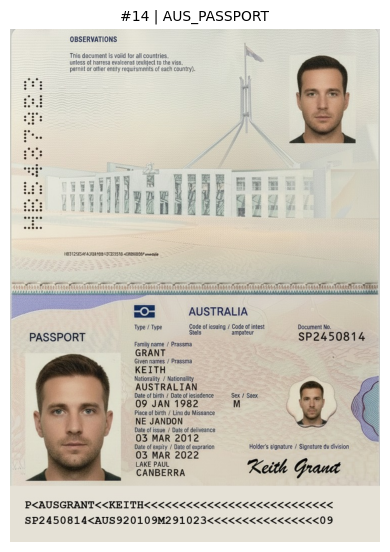

✓ valid JSON


Field,Ground Truth,Prediction
✗ authority,CANBERRA,NE JANDON
✓ date_of_birth,1982-01-09,1982-01-09
✓ date_of_expiry,2022-03-03,2022-03-03
✓ date_of_issue,2012-03-03,2012-03-03
✓ document_number,SP2450814,SP2450814
✓ document_type,AUS_PASSPORT,AUS_PASSPORT
✓ family_name,GRANT,GRANT
✓ given_names,KEITH,KEITH
✓ issuing_country,AUS,AUS
✗ mrz_line1,P<AUSGRANT<<KEITH<<<<<<<<<<<<<<<<<<<<<<<<<<<,P<AUSGRANT<<KEITH<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


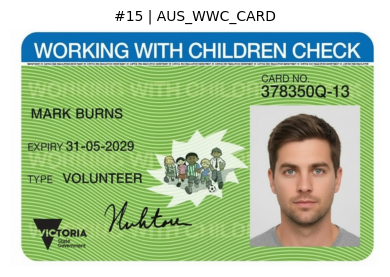

✓ valid JSON


Field,Ground Truth,Prediction
✓ document_type,AUS_WWC_CARD,AUS_WWC_CARD
✓ expiry_date,2029-05-31,2029-05-31
✓ first_name,MARK,MARK
✓ issuing_state,VIC,VIC
✓ last_name,BURNS,BURNS
✓ wwc_number,378350Q-13,378350Q-13
✓ wwc_type,VOLUNTEER,VOLUNTEER


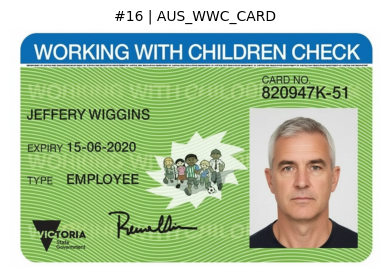

✓ valid JSON


Field,Ground Truth,Prediction
✓ document_type,AUS_WWC_CARD,AUS_WWC_CARD
✓ expiry_date,2020-06-15,2020-06-15
✓ first_name,JEFFERY,JEFFERY
✓ issuing_state,VIC,VIC
✓ last_name,WIGGINS,WIGGINS
✓ wwc_number,820947K-51,820947K-51
✓ wwc_type,EMPLOYEE,EMPLOYEE


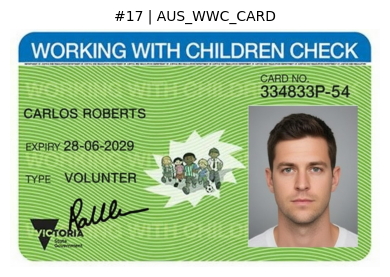

✓ valid JSON


Field,Ground Truth,Prediction
✓ document_type,AUS_WWC_CARD,AUS_WWC_CARD
✓ expiry_date,2029-06-28,2029-06-28
✓ first_name,CARLOS,CARLOS
✓ issuing_state,VIC,VIC
✓ last_name,ROBERTS,ROBERTS
✓ wwc_number,334833P-54,334833P-54
✓ wwc_type,VOLUNTEER,VOLUNTEER


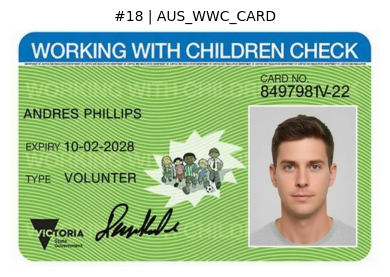

✓ valid JSON


Field,Ground Truth,Prediction
✓ document_type,AUS_WWC_CARD,AUS_WWC_CARD
✓ expiry_date,2028-02-10,2028-02-10
✓ first_name,ANDRES,ANDRES
✓ issuing_state,VIC,VIC
✓ last_name,PHILLIPS,PHILLIPS
✓ wwc_number,8497981V-22,8497981V-22
✓ wwc_type,VOLUNTEER,VOLUNTEER


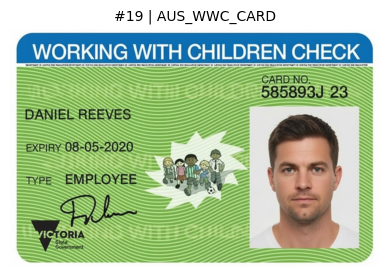

✓ valid JSON


Field,Ground Truth,Prediction
✓ document_type,AUS_WWC_CARD,AUS_WWC_CARD
✓ expiry_date,2020-05-08,2020-05-08
✓ first_name,DANIEL,DANIEL
✓ issuing_state,VIC,VIC
✓ last_name,REEVES,REEVES
✓ wwc_number,585893J 23,585893J 23
✓ wwc_type,EMPLOYEE,EMPLOYEE


In [2]:
%run ./004_batch_inference_evaluate.ipynb